In [1]:
import qiskit
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

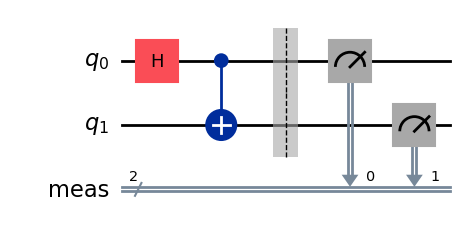

In [2]:
bell = QuantumCircuit(2)
#hadamard --superposition 0, 1
bell.h(0)
bell.cx(0, 1)

bell.measure_all()
bell.draw("mpl")

In [3]:
def run_circuit_and_get_counts(circuit, backend, shots=1000):
    """
    Runs a quantum circuit on a specified backend and returns the measurement counts.

    Args:
        circuit (QuantumCircuit): The quantum circuit to run.
        backend: The Qiskit backend (real device or simulator).
        shots (int): The number of shots to run the circuit.

    Returns:
        dict: A dictionary of measurement counts.
    """
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(circuit)

    sampler = Sampler(mode=backend)

    job = sampler.run([isa_circuit], shots=shots)
    result = job.result()

    return result[0].data.meas.get_counts()

In [4]:
from credentials import token
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=token, overwrite=True, set_as_default=True)
service = QiskitRuntimeService(channel="ibm_quantum_platform")

service = QiskitRuntimeService()

backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)

print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-04-10 00:40:47,065: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: Learning. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.__init__:WARNING:2026-04-10 00:40:50,989: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: Learning. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-10 0

ibm_fez


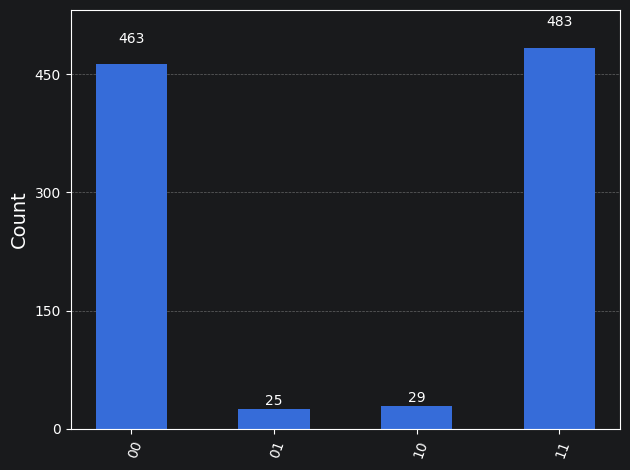

In [5]:
counts = run_circuit_and_get_counts(bell, backend, shots=1000)
plot_histogram(counts)